# Análise Exploratória: Séries Temporais de Dengue

Este notebook realiza a análise exploratória dos dados de dengue coletados via API do InfoDengue para 8 capitais brasileiras no período de 2010 a 2024.

In [1]:
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller

sns.set_theme(style="whitegrid", palette="colorblind")

CITY_LABELS = {
    "sao": "São Paulo",
    "rio": "Rio de Janeiro",
    "belo": "Belo Horizonte",
    "brasilia": "Brasília",
    "fortaleza": "Fortaleza",
    "recife": "Recife",
    "manaus": "Manaus",
    "salvador": "Salvador",
}


## 1. Carregamento dos dados

In [2]:
series_dict = {}
for fpath in sorted(glob.glob('../data/processed/dengue_monthly_*.csv')):
    city_key = Path(fpath).stem.replace('dengue_monthly_', '')
    series = pd.read_csv(fpath, index_col='date', parse_dates=['date'])['value']
    # FIX: pd.read_csv não infere freq; sem isso STL e SARIMAX falham
    series.index.freq = pd.tseries.frequencies.to_offset('MS')
    series_dict[CITY_LABELS.get(city_key, city_key)] = series

print(f'Cidades carregadas: {list(series_dict.keys())}')

Cidades carregadas: ['Belo Horizonte', 'Brasília', 'Fortaleza', 'Manaus', 'Recife', 'Rio de Janeiro', 'Salvador', 'São Paulo']


## 2. Estatísticas descritivas

In [3]:
stats = pd.DataFrame({
    city: {
        'n_meses': len(s),
        'total_casos': int(s.sum()),
        'media_mensal': round(s.mean(), 0),
        'mediana_mensal': round(s.median(), 0),
        'max_mensal': int(s.max()),
        'data_pico': str(s.idxmax().date()),
    }
    for city, s in series_dict.items()
}).T

stats

,n_meses,total_casos,media_mensal,mediana_mensal,max_mensal,data_pico
Belo Horizonte,180,1086158,6034.0,988.0,122453,2024-03-01
Brasília,180,724545,4025.0,1134.0,98704,2024-02-01
Fortaleza,180,382040,2122.0,1018.0,18986,2012-05-01
Manaus,180,132282,735.0,264.0,21605,2011-02-01
Recife,180,185593,1031.0,487.0,8504,2015-03-01
Rio de Janeiro,180,638433,3547.0,636.0,65260,2012-04-01
Salvador,180,116817,649.0,364.0,4331,2024-03-01
São Paulo,180,1711689,9509.0,1198.0,331402,2024-03-01


## 3. Visualização das séries temporais

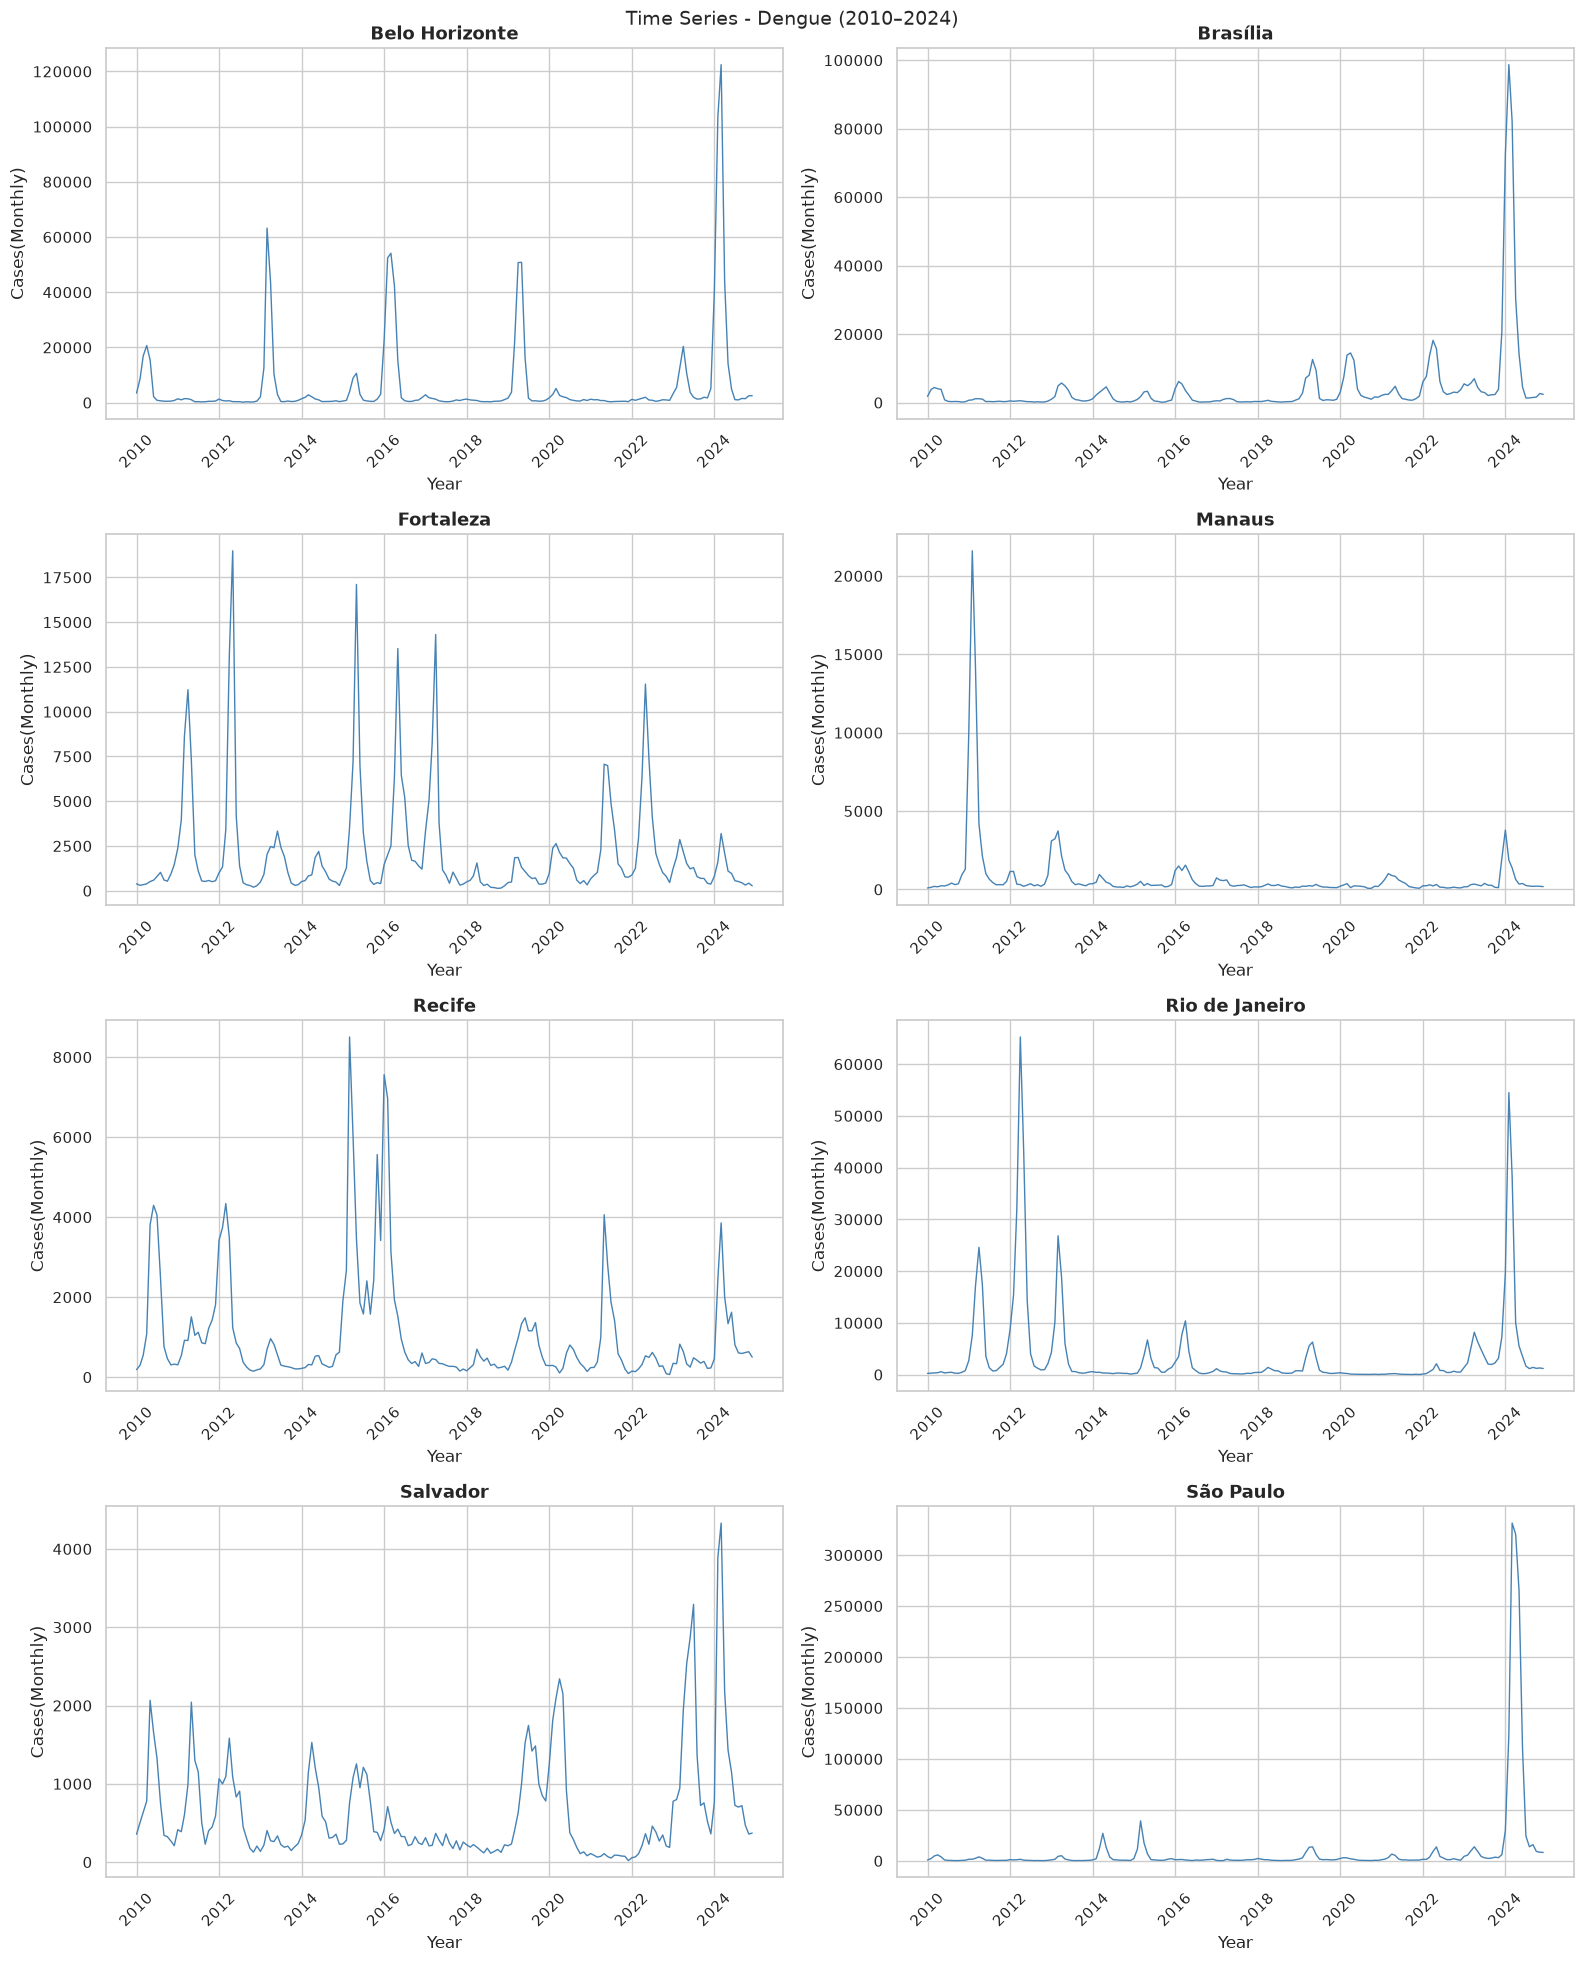

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, (city_name, series) in enumerate(series_dict.items()):
    axes[i].plot(series.index, series.values, color='steelblue', linewidth=1)
    axes[i].set_title(city_name, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Cases(Monthly)')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Time Series - Dengue (2010–2024)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Sazonalidade mensal (boxplot)

> **Correção aplicada**: substituído `sns.boxplot(color=)` + `set_xticklabels()` por
> `ax.boxplot(orientation='vertical')` do matplotlib puro. O seaborn ≥ 0.13 propaga
> internamente `vert=True` ao `ax.boxplot`, parâmetro depreciado no matplotlib ≥ 3.9.

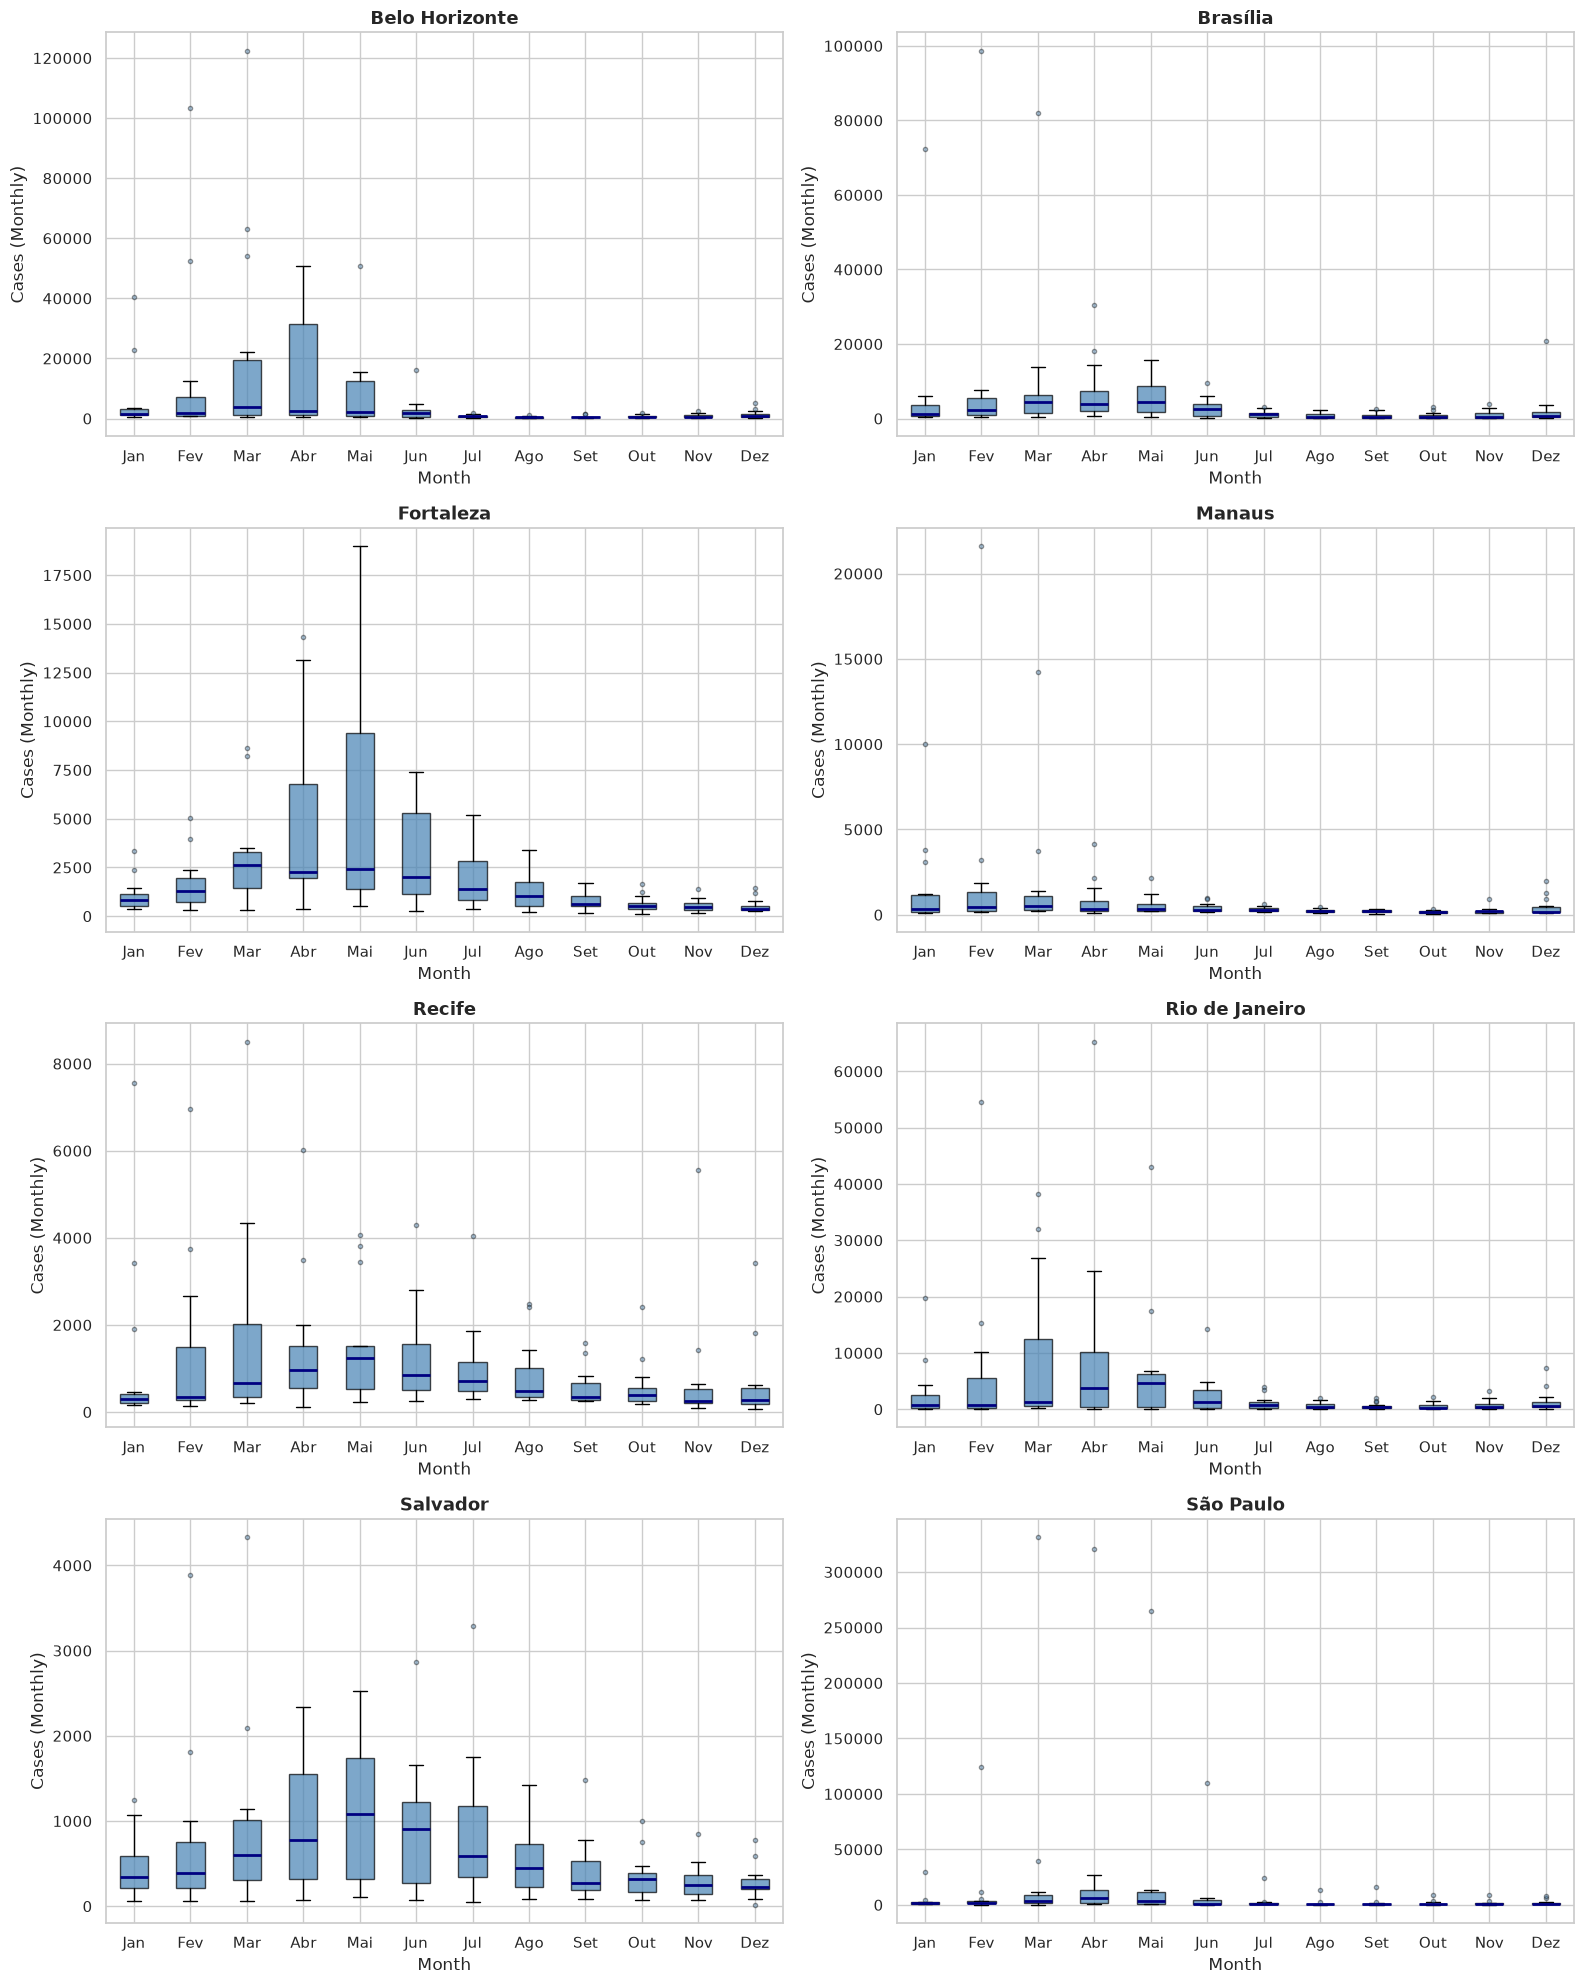

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

month_names = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

for i, (city_name, series) in enumerate(series_dict.items()):
    df_month = pd.DataFrame({'mes': series.index.month, 'casos': series.values})
    groups = [df_month[df_month['mes'] == m]['casos'].values for m in range(1, 13)]
    axes[i].boxplot(
        groups,
        orientation='vertical',
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.7),
        medianprops=dict(color='navy', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor='steelblue', markersize=3, alpha=0.4),
    )
    axes[i].set_title(city_name, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Cases (Monthly)')
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(month_names)

plt.tight_layout()
plt.show()

## 5. Correlação entre cidades

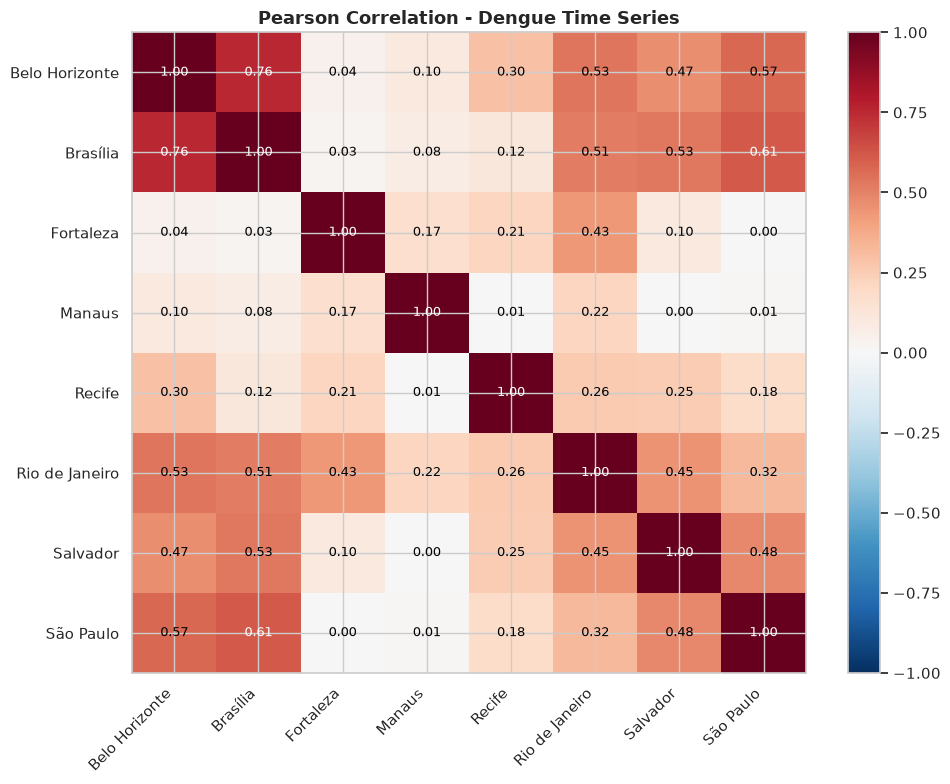

In [6]:
df_all = pd.DataFrame(series_dict)
corr = df_all.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax)

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='white' if abs(corr.iloc[i, j]) > 0.6 else 'black')

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)
ax.set_title('Pearson Correlation - Dengue Time Series', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Decomposição STL — São Paulo

A decomposição STL (Seasonal-Trend decomposition using LOESS) separa a série em
**tendência**, **sazonalidade** e **resíduo**, de forma robusta a outliers epidêmicos.
Aplicada sobre São Paulo, por ser a série de maior magnitude e principal alvo do benchmark.

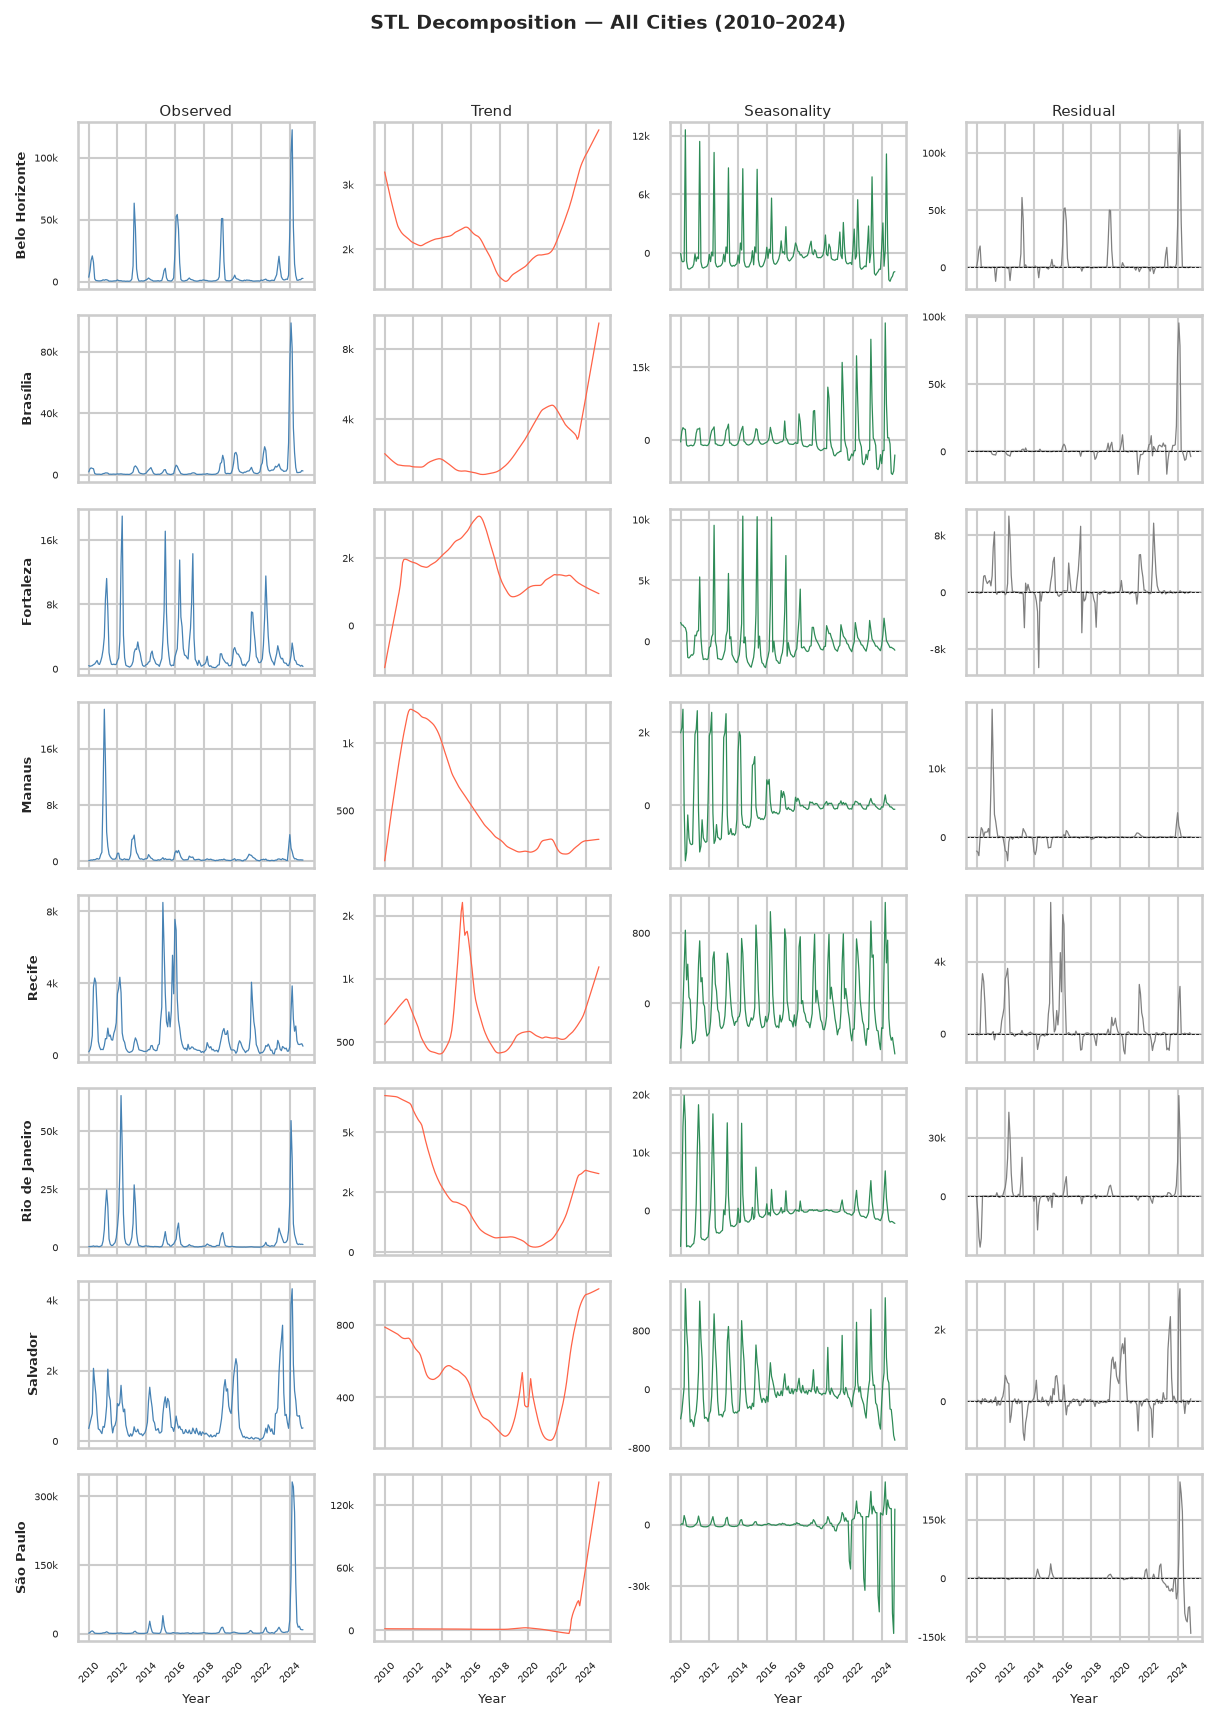

In [7]:
import matplotlib.dates as mdates
n_cities = len(series_dict)

fig, axes = plt.subplots(n_cities, 4, figsize=(8.27, 11.69), dpi=150)

for row, (city, s) in enumerate(series_dict.items()):
    stl = STL(s, period=12, robust=True)
    res = stl.fit()

    components = [s.values, res.trend, res.seasonal, res.resid]
    colors     = ['steelblue', 'tomato', 'seagreen', 'gray']
    titles     = ['Observed', 'Trend', 'Seasonality', 'Residual']

    for col, (data, color, title) in enumerate(zip(components, colors, titles)):
        ax = axes[row, col]
        ax.plot(s.index, data, color=color, linewidth=0.6)
        if col == 3:
            ax.axhline(0, color='black', linewidth=0.4, linestyle='--')

        # Column headers on first row only
        if row == 0:
            ax.set_title(title, fontsize=7, pad=3)

        # City label on first column only
        if col == 0:
            ax.set_ylabel(city, fontsize=6, fontweight='bold', labelpad=3)

        # X-axis: show only on last row, year-only ticks
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        if row == n_cities - 1:
            ax.tick_params(axis='x', labelsize=5, rotation=45)
            ax.set_xlabel('Year', fontsize=6)
        else:
            ax.tick_params(axis='x', labelbottom=False)

        ax.yaxis.set_major_locator(plt.MaxNLocator(3))
        ax.tick_params(axis='y', labelsize=5)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(
            lambda x, _: f'{x/1000:.0f}k' if abs(x) >= 1000 else f'{x:.0f}'
        ))

fig.suptitle('STL Decomposition — All Cities (2010–2024)', fontsize=9, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97], h_pad=0.8, w_pad=0.5)
plt.savefig('../results/figures/stl_decomposition_a4.pdf', format='pdf', bbox_inches='tight')
plt.show()

## 7. Teste de estacionariedade (ADF)

O teste Augmented Dickey-Fuller (ADF) avalia a hipótese nula de raiz unitária
(série não-estacionária). p < 0,05 rejeita H₀.

**Relevância para o benchmark**: séries não-estacionárias (São Paulo, Rio de Janeiro,
Fortaleza) exigem lags longos para capturar memória de longo prazo — justificando
a escolha de 24 lags — e explicam parcialmente a instabilidade do Ridge, que
assume implicitamente estacionariedade.

In [8]:
adf_rows = []
for city, s in series_dict.items():
    stat, pval, _, _, cv, _ = adfuller(s.values, autolag='AIC')
    adf_rows.append({
        'Cidade': city,
        'ADF stat': round(stat, 3),
        'p-valor': round(pval, 4),
        'VC 5%': round(cv['5%'], 3),
        'Estacionária (α=0.05)': 'Sim' if pval < 0.05 else 'Não',
    })

adf_df = pd.DataFrame(adf_rows).set_index('Cidade')
adf_df

,ADF stat,p-valor,VC 5%,Estacionária (α=0.05)
Cidade,,,,
Belo Horizonte,-5.888,0.0000,-2.878,Sim
Brasília,-3.944,0.0017,-2.878,Sim
Fortaleza,-2.784,0.0605,-2.879,Não
Manaus,-4.933,0.0000,-2.878,Sim
Recife,-3.092,0.0271,-2.879,Sim
Rio de Janeiro,-2.257,0.1861,-2.879,Não
Salvador,-4.024,0.0013,-2.879,Sim
São Paulo,1.822,0.9984,-2.879,Não
